<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (5572, 2)

First 5 Rows:
  Category                                           Masseges
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Missing Values:
Category    0
Masseges    0
dtype: int64

Training Data: (4457, 5000)
Testing Data: (1115, 5000)

DECISION TREE ACCURACY
Accuracy: 95.52%

Confusion Matrix:
[[953  13]
 [ 37 112]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      0.99      0.97       966
        spam       0.90      0.75      0.82       149

    accuracy                           0.96      1115
   macro avg       0.93      0.87      0.90      1115
weighted avg       0.95      0.96      0.95      1115



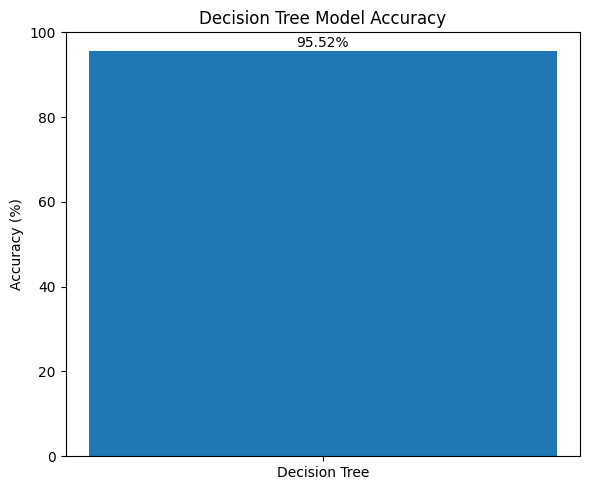

In [1]:
# ============================================
# DECISION TREE - SPAM MAIL CLASSIFICATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------

df = pd.read_csv("spam mail.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# --------------------------------------------
# 2. Check Missing Values
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# --------------------------------------------
# 3. Remove Missing Values
# --------------------------------------------

df = df.dropna()


# --------------------------------------------
# 4. Separate Features and Target
# --------------------------------------------

X = df["Masseges"]
y = df["Category"]


# --------------------------------------------
# 5. Convert Text into Numerical Features
# --------------------------------------------

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(X)


# --------------------------------------------
# 6. Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# --------------------------------------------
# 7. Create Decision Tree Model
# --------------------------------------------

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=20
)


# --------------------------------------------
# 8. Train the Model
# --------------------------------------------

model.fit(
    X_train,
    y_train
)


# --------------------------------------------
# 9. Make Predictions
# --------------------------------------------

y_pred = model.predict(X_test)


# --------------------------------------------
# 10. Calculate Accuracy
# --------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================================")
print("DECISION TREE ACCURACY")
print("================================")

print(f"Accuracy: {accuracy * 100:.2f}%")


# --------------------------------------------
# 11. Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# --------------------------------------------
# 12. Classification Report
# --------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# --------------------------------------------
# 13. Accuracy Graph
# --------------------------------------------

plt.figure(figsize=(6, 5))

plt.bar(
    ["Decision Tree"],
    [accuracy * 100]
)

plt.ylabel("Accuracy (%)")

plt.title(
    "Decision Tree Model Accuracy"
)

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.tight_layout()

plt.show()